# 03 — Feature Engineering: PCOS Symptoms Dataset

**Goal:** Transform raw symptom data into a clean, encoded, model-ready feature matrix.

**What we do here and why:**
| Step | What | Why |
|------|------|-----|
| 1 | Repeat cleaning from EDA | Always start fresh from raw data so this notebook is self-contained |
| 2 | Encode binary Yes/No columns | Models need numbers, not strings |
| 3 | Encode "I do not know" as a 3rd category | IDK rate (44%) ≠ overall PCOS rate (76%) → IDK carries signal |
| 4 | Ordinal encode scaled columns | Preserve order: Normal < Medium < High < Extreme |
| 5 | Drop near-zero Cramér's V features | `Ex_pain_abdominal` (V=0.0), `Mood_swing_normal` (V=0.02) add noise |
| 6 | Handle class imbalance with SMOTE | 76% PCOS / 24% non-PCOS → model will predict PCOS always without fix |
| 7 | Save processed data + encoders | Training notebook loads these; FastAPI loads encoders at inference |


In [2]:
import pandas as pd
import numpy as np
import joblib, os
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import OrdinalEncoder
import warnings
warnings.filterwarnings("ignore") # ignore any warning messages 

# Create directories
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../models/encoders", exist_ok=True)


## 1. Load & Repeat Cleaning

 — Always load raw data and clean from scratch.

In [3]:
df = pd.read_csv("../data/raw/PCOS_symptoms.csv")

# ── Fix column name spaces ────────────────────────────────
df.columns = df.columns.str.strip()

# ── Drop impossible height/BMI rows ──────────────────────
df = df[(df["Height(m)"] != 0) & (df["BMI(kg/m*m)"] != 0)].reset_index(drop=True)

# ── Fix dirty Hormonal_imbalance value '2' ────────────────
df["Hormonal_imbalance"] = df["Hormonal_imbalance"].replace("2", np.nan)
df["Hormonal_imbalance"] = df["Hormonal_imbalance"].fillna(
    df["Hormonal_imbalance"].mode()[0]
)

# ── Standardise Cyst_ovary casing ────────────────────────
df["Cyst_ovary"] = (
    df["Cyst_ovary"].str.strip().str.title()
    .replace({"I Do Not Know": "I do not know"})
)

print(f"Shape after cleaning: {df.shape}")
print(f"Class balance:\n{df['PCOS'].value_counts().to_string()}")


Shape after cleaning: (682, 33)
Class balance:
PCOS
1    519
0    163


## 2. Feature Groups

We split every column into groups based on what encoding strategy they need.
This is the decision map:

| Group | Columns | Strategy |
|-------|---------|----------|
| Binary Yes/No | `Overweight`, `Excess_facial_hair` … | Map Yes→1, No→0 |
| Binary Irregular/Regular | `Period_type` | Map Irregular→1, Regular→0 (Irregular = risk factor) |
| 3-category with IDK | `LH_hormone`, `Cyst_ovary` … | Ordinal: Normal/No→0, IDK→1, Abnormal/Yes→2 |
| 3-category with Maybe | `Gain_weight`, `Slow_activity` | Ordinal: No→0, Maybe→1, Yes→2 |
| 3-category other | `Ex_pain_abdominal`, `Blood_pressure`, `Diagnosis_age` | Different treatment — see below |
| 4-level mood/craving | `Mood_swing_period`, `Craving_PT` | Ordinal: Normal→0, Medium→1, High→2, Extreme→3 |
| Numerical | `Weight`, `Height`, `BMI` | Keep as-is |
| DROP | `Mood_swing_normal`, `Ex_pain_abdominal` | Cramér's V ≈ 0 → no predictive power |


In [4]:
TARGET = "PCOS"

# ── Columns to DROP (Cramér's V too low to be useful) ─────
# Mood_swing_normal: V=0.019, Ex_pain_abdominal: V=0.000
DROP_COLS = ["Mood_swing_normal", "Ex_pain_abdominal"]

# ── Binary Yes/No (Yes=1, No=0) ───────────────────────────
BINARY_YESNO = [
    "Family_background", "Overweight", "Hormonal_imbalance",
    "Excess_facial_hair", "Excess_body_hair", "Dark_area",
    "Pimple_face", "Hormonal_acne_face", "Fast_food",
    "Losing_hair", "Depress", "Mental_stress", "Insomnia",
    "Cyst_ovary",  # handled separately below (has IDK)
]
# Remove Cyst_ovary from yes/no — it has 3 levels
BINARY_YESNO = [c for c in BINARY_YESNO if c not in ["Cyst_ovary", "Family_background"]]

# Straight binary (no IDK)
STRAIGHT_BINARY_YESNO = [
    "Overweight", "Hormonal_imbalance", "Excess_facial_hair",
    "Excess_body_hair", "Dark_area", "Pimple_face",
    "Hormonal_acne_face", "Fast_food", "Losing_hair",
    "Depress", "Mental_stress", "Insomnia",
]

# ── Binary special ────────────────────────────────────────
PERIOD_COL = "Period_type"           # Irregular=1, Regular=0

# ── 3-category with IDK: Normal/No=0, IDK=1, Abnormal/Yes=2
IDK_HORMONE_COLS = [
    "LH_hormone", "FSH_hormone", "Diabetes_measurment",
    "TSH_hormone", "Prolactin_hormone", "Hemoglobin_level",
]
IDK_BINARY_COLS = ["Family_background", "Cyst_ovary"]  # Yes/No/IDK

# ── 3-category: No=0, May be=1, Yes=2 ────────────────────
MABYE_COLS = ["Gain_weight", "Slow_activity"]

# ── 3-category: Blood_pressure ────────────────────────────
# Low=0, Normal=1, High=2  (ordinal risk)
BLOOD_PRESSURE_COL = "Blood_pressure"

# ── Diagnosis_age ordinal ─────────────────────────────────
# Youth=0, Young adult=1, Adult=2
DIAG_AGE_COL = "Diagnosis_age"

# ── 4-level ordinal ───────────────────────────────────────
ORDINAL4_COLS = ["Mood_swing_period", "Craving_PT"]

# ── Numerical ─────────────────────────────────────────────
NUMERICAL_COLS = ["Weight(kg)", "Height(m)", "BMI(kg/m*m)"]

print("Feature groups defined ✓")


Feature groups defined ✓


## 3. Binary Encoding

In [5]:
# ── Straight binary: Yes→1, No→0 ─────────────────────────
yes_no_map = {"Yes": 1, "No": 0}
for col in STRAIGHT_BINARY_YESNO:
    df[col] = df[col].map(yes_no_map)
    n_null = df[col].isnull().sum()
    if n_null > 0:
        print(f"  ⚠ {col}: {n_null} unmapped values → filling with mode")
        df[col] = df[col].fillna(df[col].mode()[0])

# ── Period type: Irregular (risk factor)=1, Regular=0 ────
df[PERIOD_COL] = df[PERIOD_COL].map({"Irregular": 1, "Regular": 0})

print("Binary encoding done.")
print(df[STRAIGHT_BINARY_YESNO + [PERIOD_COL]].head(3).to_string())


Binary encoding done.
   Overweight  Hormonal_imbalance  Excess_facial_hair  Excess_body_hair  Dark_area  Pimple_face  Hormonal_acne_face  Fast_food  Losing_hair  Depress  Mental_stress  Insomnia  Period_type
0           1                   1                   1                 1          0            1                   1          1            1        1              1         0            1
1           0                   1                   1                 1          1            1                   1          1            1        0              0         1            0
2           0                   0                   0                 1          1            0                   0          1            0        1              1         1            0


## 4. Encoding 'I do not know' as a Third Category

From EDA: people who answered IDK had only ~44% PCOS rate vs 76% overall.
IDK is therefore a meaningful signal — people who don't know their hormone levels likely haven't been investigated for PCOS.

Encoding: **Normal/No → 0, I do not know → 1, Abnormal/Yes → 2**

In [6]:
# ── Hormone columns: Normal=0, IDK=1, Abnormal=2 ─────────
hormone_map = {"Normal": 0, "I do not know": 1, "Abnormal": 2}
for col in IDK_HORMONE_COLS:
    df[col] = df[col].map(hormone_map)
    n_null = df[col].isnull().sum()
    if n_null > 0:
        print(f"  ⚠ {col}: {n_null} unmapped → filling 1 (IDK)")
        df[col] = df[col].fillna(1)

# ── Binary IDK columns: No=0, IDK=1, Yes=2 ───────────────
binary_idk_map = {"No": 0, "I do not know": 1, "Yes": 2}
for col in IDK_BINARY_COLS:
    df[col] = df[col].map(binary_idk_map)
    n_null = df[col].isnull().sum()
    if n_null > 0:
        print(f"  ⚠ {col}: {n_null} unmapped → filling 1 (IDK)")
        df[col] = df[col].fillna(1)

print("IDK encoding done.")
print(df[IDK_HORMONE_COLS + IDK_BINARY_COLS].head(3).to_string())


IDK encoding done.
   LH_hormone  FSH_hormone  Diabetes_measurment  TSH_hormone  Prolactin_hormone  Hemoglobin_level  Family_background  Cyst_ovary
0           0            2                    2            2                  0                 0                  2           2
1           1            1                    1            1                  1                 1                  1           1
2           1            1                    1            1                  1                 1                  1           1


## 5. Ordinal Encoding

In [7]:
# ── Gain_weight / Slow_activity: No=0, May be=1, Yes=2 ───
mabye_map = {"No": 0, "May be": 1, "Yes": 2}
for col in MABYE_COLS:
    df[col] = df[col].map(mabye_map)

# ── Blood_pressure: Low=0, Normal=1, High=2 ───────────────
df[BLOOD_PRESSURE_COL] = df[BLOOD_PRESSURE_COL].map({"Low": 0, "Normal": 1, "High": 2})

# ── Diagnosis_age: Youth=0, Young adult=1, Adult=2 ────────
df[DIAG_AGE_COL] = df[DIAG_AGE_COL].map({"Youth": 0, "Young adult": 1, "adult": 2})

# ── Mood_swing_period / Craving_PT ────────────────────────
# Normal=0, Medium=1, High=2, Extreme=3
mood_map = {"Normal": 0, "Medium": 1, "High": 2, "Extreme": 3}
for col in ORDINAL4_COLS:
    df[col] = df[col].map(mood_map)

print("Ordinal encoding done.")
print(df[MABYE_COLS + [BLOOD_PRESSURE_COL, DIAG_AGE_COL] + ORDINAL4_COLS].head(3).to_string())


Ordinal encoding done.
   Gain_weight  Slow_activity  Blood_pressure  Diagnosis_age  Mood_swing_period  Craving_PT
0            2              2               1              0                  2           2
1            1              2               2              2                  2           2
2            0              2               0              2                  2           2


## 6. Drop Low-Signal Features

In [8]:
print(f"Shape before drop: {df.shape}")
df = df.drop(columns=DROP_COLS)
print(f"Shape after drop:  {df.shape}")
print(f"Dropped: {DROP_COLS}")
print()

# Final check — no strings remaining, no nulls
str_remaining = [c for c in df.columns if df[c].dtype == object]
null_counts   = df.isnull().sum()
null_cols     = null_counts[null_counts > 0]

print(f"String columns remaining: {str_remaining}")
if str_remaining:
    for col in str_remaining:
        print(f"  {col}: {df[col].unique()}")

print(f"\nNull counts:")
if len(null_cols) > 0:
    print(null_cols.to_string())
else:
    print("  None ✓")


Shape before drop: (682, 33)
Shape after drop:  (682, 31)
Dropped: ['Mood_swing_normal', 'Ex_pain_abdominal']

String columns remaining: []

Null counts:
  None ✓


## 7. Final Feature Matrix

In [9]:
# Separate features (X) and target (y)
X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nClass distribution (before SMOTE):")
print(y.value_counts().to_string())
print(f"\nFeatures ({len(X.columns)}):")
for col in X.columns:
    print(f"  {col:<35} dtype={X[col].dtype}  range=[{X[col].min():.1f}, {X[col].max():.1f}]")


X shape: (682, 30)
y shape: (682,)

Class distribution (before SMOTE):
PCOS
1    519
0    163

Features (30):
  Family_background                   dtype=int64  range=[0.0, 2.0]
  LH_hormone                          dtype=int64  range=[0.0, 2.0]
  FSH_hormone                         dtype=int64  range=[0.0, 2.0]
  Diabetes_measurment                 dtype=int64  range=[0.0, 2.0]
  TSH_hormone                         dtype=int64  range=[0.0, 2.0]
  Prolactin_hormone                   dtype=int64  range=[0.0, 2.0]
  Hemoglobin_level                    dtype=int64  range=[0.0, 2.0]
  Cyst_ovary                          dtype=int64  range=[0.0, 2.0]
  Diagnosis_age                       dtype=int64  range=[0.0, 2.0]
  Overweight                          dtype=int64  range=[0.0, 1.0]
  Period_type                         dtype=int64  range=[0.0, 1.0]
  Hormonal_imbalance                  dtype=int64  range=[0.0, 1.0]
  Gain_weight                         dtype=int64  range=[0.0, 2.0]
  Exce

## 8. Handle Class Imbalance with SMOTE

**Why SMOTE and not just random oversampling?**

Random oversampling duplicates existing minority rows — the model memorizes them.
SMOTE (Synthetic Minority Over-sampling Technique) creates *new synthetic samples* by interpolating between real minority class examples. This gives the model genuinely new patterns to learn from.

**Important rule:** SMOTE is applied ONLY on training data. Never on test data. We do the split first.

In [10]:
from sklearn.model_selection import train_test_split

# ── Train/test split BEFORE SMOTE ─────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")
print(f"\nTrain class distribution (before SMOTE):")
print(y_train.value_counts().to_string())

# ── Apply SMOTE on train only ──────────────────────────────
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nTrain class distribution (after SMOTE):")
print(pd.Series(y_train_sm).value_counts().to_string())
print(f"\nNew train size: {X_train_sm.shape[0]}")


Train size: 545  |  Test size: 137

Train class distribution (before SMOTE):
PCOS
1    415
0    130

Train class distribution (after SMOTE):
PCOS
0    415
1    415

New train size: 830


## 9. Save Processed Data

In [11]:
import joblib

# ── Save train/test splits ─────────────────────────────────
pd.DataFrame(X_train_sm).to_csv("../data/processed/symptoms_X_train.csv", index=False)
pd.Series(y_train_sm, name="PCOS").to_csv("../data/processed/symptoms_y_train.csv", index=False)
X_test.to_csv("../data/processed/symptoms_X_test.csv", index=False)
y_test.to_csv("../data/processed/symptoms_y_test.csv", index=False)

# ── Save feature column order ─────────────────────────────
# FastAPI must receive features in EXACTLY this order at inference
feature_columns = X.columns.tolist()
joblib.dump(feature_columns, "../models/encoders/symptoms_feature_columns.pkl")

# ── Save encoding maps (for FastAPI preprocessing) ────────
encoding_maps = {
    "binary_yesno":    STRAIGHT_BINARY_YESNO,
    "period_col":      PERIOD_COL,
    "hormone_map":     {"cols": IDK_HORMONE_COLS, "map": {"Normal": 0, "I do not know": 1, "Abnormal": 2}},
    "binary_idk_map":  {"cols": IDK_BINARY_COLS,  "map": {"No": 0, "I do not know": 1, "Yes": 2}},
    "mabye_map":       {"cols": MABYE_COLS,        "map": {"No": 0, "May be": 1, "Yes": 2}},
    "blood_pressure":  {"col": BLOOD_PRESSURE_COL, "map": {"Low": 0, "Normal": 1, "High": 2}},
    "diagnosis_age":   {"col": DIAG_AGE_COL,       "map": {"Youth": 0, "Young adult": 1, "adult": 2}},
    "mood_map":        {"cols": ORDINAL4_COLS,      "map": {"Normal": 0, "Medium": 1, "High": 2, "Extreme": 3}},
    "drop_cols":       DROP_COLS,
    "numerical_cols":  NUMERICAL_COLS,
}
joblib.dump(encoding_maps, "../models/encoders/symptoms_encoding_maps.pkl")

print("Saved:")
print("  ../data/processed/symptoms_X_train.csv")
print("  ../data/processed/symptoms_y_train.csv")
print("  ../data/processed/symptoms_X_test.csv")
print("  ../data/processed/symptoms_y_test.csv")
print("  ../models/encoders/symptoms_feature_columns.pkl")
print("  ../models/encoders/symptoms_encoding_maps.pkl")


Saved:
  ../data/processed/symptoms_X_train.csv
  ../data/processed/symptoms_y_train.csv
  ../data/processed/symptoms_X_test.csv
  ../data/processed/symptoms_y_test.csv
  ../models/encoders/symptoms_feature_columns.pkl
  ../models/encoders/symptoms_encoding_maps.pkl


## 10. Quick Sanity Check

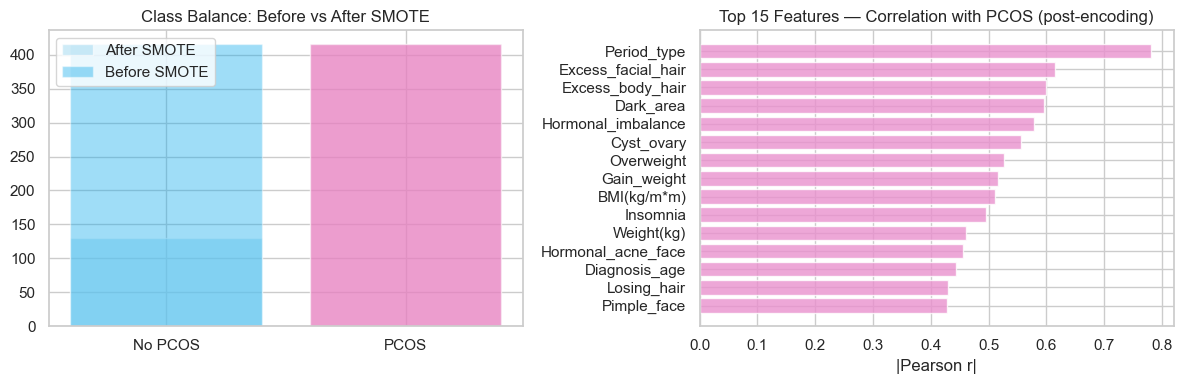


Top 10 correlated features after encoding:
Period_type           0.780939
Excess_facial_hair    0.614627
Excess_body_hair      0.598945
Dark_area             0.595141
Hormonal_imbalance    0.579055
Cyst_ovary            0.555981
Overweight            0.525853
Gain_weight           0.515756
BMI(kg/m*m)           0.511382
Insomnia              0.495233
Weight(kg)            0.461654
Hormonal_acne_face    0.455205
Diagnosis_age         0.444225
Losing_hair           0.429892
Pimple_face           0.428397


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class balance before vs after SMOTE
axes[0].bar(["No PCOS", "PCOS"], y_train.value_counts().sort_index().values,
            color=["#AEDEF2", "#F7B3E3"], alpha=0.6, label="After SMOTE")
axes[0].bar(["No PCOS", "PCOS"],
            pd.Series(y_train_sm).value_counts().sort_index().values,
            color=["#11AAEB", "#D94FA0"], alpha=0.4, label="Before SMOTE")
axes[0].set_title("Class Balance: Before vs After SMOTE")
axes[0].legend()

# Feature value distributions (sample of key features)
key_features = ["Period_type", "Cyst_ovary", "Prolactin_hormone", "BMI(kg/m*m)"]
key_features = [f for f in key_features if f in X_train_sm.columns]
X_check = pd.DataFrame(X_train_sm, columns=X.columns)
X_check["PCOS"] = y_train_sm

corr_check = X_check.corr()["PCOS"].drop("PCOS").abs().sort_values(ascending=False)
axes[1].barh(corr_check.index[:15][::-1], corr_check.values[:15][::-1],
             color="#E991CE", alpha=0.8)
axes[1].set_title("Top 15 Features — Correlation with PCOS (post-encoding)")
axes[1].set_xlabel("|Pearson r|")

plt.tight_layout()
plt.show()

print("\nTop 10 correlated features after encoding:")
print(corr_check.head(15).to_string())


## Summary

```
Final feature matrix (symptoms):
  Train: SMOTE-balanced, ready for model training
  Test:  Original distribution (no SMOTE), for honest evaluation

Encoding applied:
  - 12 binary Yes/No      → 0/1
  - Period_type           → Irregular=1, Regular=0
  - 6 hormone cols (IDK)  → Normal=0, IDK=1, Abnormal=2
  - 2 binary IDK cols     → No=0, IDK=1, Yes=2  
  - 2 Maybe cols          → No=0, Maybe=1, Yes=2
  - Blood_pressure        → Low=0, Normal=1, High=2
  - Diagnosis_age         → Youth=0, YoungAdult=1, Adult=2
  - 2 mood/craving cols   → Normal=0, Medium=1, High=2, Extreme=3
  - 2 features DROPPED    → Mood_swing_normal (V=0.02), Ex_pain_abdominal (V=0.00)
  - 3 numerical kept as-is

```